This is starter code that implements a Cell-free massive MIMO system

In [1]:
import ipdb
from scipy import linalg
from typing import Optional
import random
import numpy as np
import torch
import numba
import copy
import matplotlib.pyplot as plt
import time
%matplotlib widget

This function places APs and UEs uniformly randlomly in a 1km*1km square area. Then we wrap it around to account for boundary effects and simulate an infinite area. We then compute the distances between each AP and UE and feed that into the propagation model. We also do pilot allocation here. 

In [2]:
## generate random setup with AP and UE locations, and compute spatial correlation
#matrices and LSF gain, assign pilots and return initial allocation as best APs
## parameters 
#M- number of Access points
#K- number of users
#dcorr- decorrelation distance - input for propagation model
#sigma - standard deviation - for shadow fading 
#antennas - number of antennas per AP
#PNlog - thermal noise in dB - KTB (boltmanns constant, temperature, bandwidth)
#tau_p - number of pilot symbols 
#hap - AP height 
#hue - UE height

def setup(M,K,dcorr,delta,sigma,antennas,PNlog,tau_p,hap,hue):
    
    #place APs
    AP=np.empty([M,9],dtype=np.complex128)
    AP0=np.empty(M,dtype=np.complex128)
    AP0.real=np.random.uniform(-0.5,0.5,M)
    AP0.imag=np.random.uniform(-0.5,0.5,M) # initial positions
    AP[:,0]=AP0
    AP[:,1]=AP0+1
    AP[:,2]=AP0-1
    AP[:,3]=AP0+1j
    AP[:,4]=AP0-1j
    AP[:,5]=AP0+1+1j
    AP[:,6]=AP0+1-1j
    AP[:,7]=AP0-1-1j
    AP[:,8]=AP0-1+1j
    #compute AP-AP distance
    APdistance=np.zeros([M,M],dtype=np.float64)
    for i in range(M):
        distAP=np.abs(AP[i,0]-AP)
        APdistance[i,:]=np.min(distAP,axis=1)
    APcorrelation=2**(-APdistance/dcorr)
    
    #place UEs
    UE=np.empty([K,9],dtype=np.complex128)
    UE0=np.empty(K,dtype=np.complex128)
    UE0.real=np.random.uniform(-0.5,0.5,K)
    UE0.imag=np.random.uniform(-0.5,0.5,K) # initial positions
    UE[:,0]=UE0
    UE[:,1]=UE0+1
    UE[:,2]=UE0-1
    UE[:,3]=UE0+1j
    UE[:,4]=UE0-1j
    UE[:,5]=UE0+1+1j
    UE[:,6]=UE0+1-1j
    UE[:,7]=UE0-1-1j
    UE[:,8]=UE0-1+1j
    
    #compute UE-UEdistance
    UEdistance=np.zeros([K,K],dtype=np.float64)
    for i in range(K):
        distUE=np.abs(UE[i,0]-UE)
        UEdistance[i,:]=np.min(distUE,axis=1)
    UEcorrelation=2**(-UEdistance/dcorr)
  
    #compute shadow fading
    APshadow=np.sqrt(delta)*sigma*np.matmul(linalg.sqrtm(APcorrelation),np.random.normal(0,1,M))
    UEshadow=np.sqrt(1-delta)*sigma*np.matmul(linalg.sqrtm(UEcorrelation),np.random.normal(0,1,K))
    Z_shadow=np.zeros([M,K])
    for m in range(M):
        for k in range(K):
            Z_shadow[m,k]=APshadow[m]+UEshadow[k]
    # compute large scale fading coefficient beta
    distance=np.zeros([M,K]) #AP-UE distance
    pos=np.zeros([M,K]) # arg of minimum distance AP for spatial correlation
    
    for k in range(K):
            dist=np.abs(UE[k,0]-AP)
            distance[:,k]=np.min(dist,axis=1)
            pos[:,k]=np.argmin(dist,axis=1)
   
    distance=np.sqrt((distance*1000)**2+np.array((hap-hue)**2))
    BETAdB=-30.5-36.7*np.log10(distance)+Z_shadow
    gainovernoisedB=BETAdB-np.array(PNlog) ## cnat subract np array and tensor
    gainovernoise=10**(gainovernoisedB/10).astype(np.float64) #gain over noise  linear
    #uncorrelated rayleigh 
   
    # apply spatial correlation
    R=np.zeros((antennas,antennas,M,K),dtype='complex')
    for k in range(K):
        for m in range(M):
            
            R[:,:,m,k]=gainovernoise[m,k]*np.eye(antennas)

    #Pilot allocation based on the paper: ``Scalable Cell-Free Massive MIMO Systems,” 
    #by Emil Björnson and Luca Sanguinetti, IEEE Transactions on Communications
    
    
    #get master AP
    ServingAPsDCC=np.zeros((M,K),dtype=np.int64)
    masterAPs=np.zeros(K,dtype=int)
    pilotIndex=np.zeros(K,dtype=int)
    
    for k in range(K):
        master=np.argmax(gainovernoisedB[:,k])
        #print(master)
        masterAPs[k]=master
        ServingAPsDCC[master,k]=1
        #assign orthogonalpilots to first tau_p Ues
        if k<tau_p:
            pilotIndex[k]=k
        else:
            pilotinterference=np.zeros(tau_p)
            for t in range(tau_p):
                pilotinterference[t]=np.sum(gainovernoise[master,np.where\
                                                          (pilotIndex[0:k]==t)])
            
            bestpilot=np.argmin(pilotinterference)
            pilotIndex[k]=bestpilot
            #print(pilotinterference)
            #print(bestpilot)
    
    
    return(UE,AP,R,distance,gainovernoisedB,gainovernoise,pilotIndex)
    # The funcion returns 
    #UE- UE locations (x+jy) - x and y coordinates
    #AP- AP locations (x+jy)- x and y coordinates 
    #distance - an M*K matrix with distances between each AP and UE 
    #gainovernoise- this is the large scale fading gain over the thermal noise
    #pilotIndex - a K-dimensional vector with the index of the pilot allocated to each UE
    #R - spatial correlation matrix - needed to compute the channel estimates 
    

In [3]:
### compute channel estimates
# This function computes the estimate of the channel Hhat between each AP and UE
# p - uplink pilot power 
#channels - random channel realizations 
def ChannelEstimates(M,antennas,channels,K,p,tau_p,pilotIndex,R):
        H=np.random.normal(0,1,(M*antennas,channels,K))+1j*np.random.normal\
            (0,1,(M*antennas,channels,K))
        # apply corelation matrices to channels
        for m in range(M):
            for k in range(K):
                Rsqrt=linalg.sqrtm(R[:,:,m,k])
                H[antennas*m:antennas*(m+1),:,k]=np.sqrt(0.5)*np.matmul\
                    (Rsqrt,H[antennas*m:antennas*(m+1),:,k])
        eyeN=np.eye(antennas)
        #generate noise
        Np=np.sqrt(0.5)*(np.random.normal(0,1,(antennas,channels,M,tau_p))\
                         +1j*np.random.normal(0,1,(antennas,channels,M,tau_p)))
        Hhat=np.zeros((M*antennas,channels,K),dtype=np.complex128)
        B=np.zeros(R.shape,dtype='complex')
        C=np.zeros(R.shape,dtype='complex')
        for m in range(M):
            for t in range(tau_p):
                #compute processed signal for all UEs using pilot t
                yp=np.sqrt(p)*tau_p*np.sum(H[antennas*m:antennas*(m+1),:,t==pilotIndex],\
                                           axis=2)+np.sqrt(tau_p)*Np[:,:,m,t]
                PsiInv=(p*tau_p*np.sum(R[:,:,m,t==pilotIndex],axis=2)+eyeN)
                Pilot_t_UEs=np.where(pilotIndex==t)[0] #uses which use pilot t
                for k in Pilot_t_UEs:
                    RPsi=R[:,:,m,k]/PsiInv
                    #MMSE estimate
                    Hhat[antennas*m:antennas*(m+1),:,k]=np.sqrt(p)*np.matmul(RPsi,yp)
                    #spatial correlation matrix of estimate
                    B[:,:,m,k]=p*tau_p*np.matmul(RPsi,R[:,:,m,k])
                    #spatial correlation matrix of the estimation error
                    C[:,:,m,k]=R[:,:,m,k]-B[:,:,m,k]
        return(H,Hhat,B,C)
    #outputs H- matrix of channel realizations, Hhat - matrix of channel extimates , B and C correlation matrices of the estimation error and 
    #the channel estimate. Refer to section 1.7 in project description

In [4]:
#  we use number to speed up parallel computation 
#this function implements the Spectral efficiency equation 
#Pd- downlink max transmit power 
@numba.jit
def compute_rates1(M,K,APs,gainovernoise,Pd,tau_p,tau_c,B,R,pilotIndex):
    # compute power allocation based on algorithm described in section 1.4
    Power=np.zeros((M,K),dtype=np.float32) # M by K power allocation matrix
    #indicated the power allocated to each UE by each AP.
    for m in range(M):
        servedUEs=np.where(APs[m,:]==1)[0]
        denominator=np.sum(np.sqrt(gainovernoise[m,servedUEs]))
        for k in servedUEs:
            Power[m,k]=Pd*np.sqrt(gainovernoise[m,k])/denominator  
#compute SEs
    signal_MR=np.zeros(K,dtype=np.float32)
    interf_MR=np.zeros(K,dtype=np.float32)
    cont_MR=np.zeros((K,K),dtype=np.float32)
    pre_logfactor=1-tau_p/tau_c
    for m in range(M):
        servedUEs=np.where(APs[m,:]==1)[0]
        for k in servedUEs:
            signal_MR[k]=signal_MR[k]+np.sqrt(Power[m,k]*np.real(np.trace(B[:,:,m,k])))
            for i in range(K):
                B_k=np.copy(B[:,:,m,k])
                R_i=np.copy(R[:,:,m,i])
                R_k=np.copy(R[:,:,m,k])
                interf_MR[i]=interf_MR[i]+Power[m,k]*\
                    np.real(np.trace(np.dot(B_k,R_i)))/np.real(np.trace(B_k))
                if pilotIndex[k]==pilotIndex[i]:
                    cont_MR[i,k]=cont_MR[i,k]+np.sqrt(Power[m,k])*\
                        np.real(np.trace(np.dot((np.dot(B_k,np.linalg.inv(R_k))),R_i)))\
                            /np.sqrt(np.real(np.trace(B_k)))
    SINR=(np.abs(signal_MR)**2)/(interf_MR+np.sum(np.abs(cont_MR)**2,axis=1)-np.abs(signal_MR)**2+1)
    SE_MR=pre_logfactor*np.real(np.log2(1+SINR)) 
    return(SE_MR,SINR,Power)
    #returns SE for each UE, SINR for each UE, Power allocated 

In [5]:
#This function implements an AP-UE association algorithm based on the LSF gain. The ouptut is an M*K matrix where 1 indicates that AP M serves UE K
#And 0 indicates that AP m does not serve UE k. you will be implementing similar algorithms. Save your allocation in a similar M*K matrix
def BetaAPs(M,K,gainovernoise): 
    ServingAPsBeta=np.zeros((M,K)) 
    for k in range(K): 
        
        gain=gainovernoise[:,k]
        sorted_gain=np.sort(gain)[::-1]## sort in descending order
        current_gain=np.zeros(M)
        for m in range(M): 
            current_gain[m]=np.sum(sorted_gain[:m+1])/np.sum(sorted_gain)
        #ipdb.set_trace()
        stopindex=np.where(current_gain>=0.95)[0][0]
        #ipdb.set_trace()
        for id in range(stopindex+1):
            AP=np.where(gain==sorted_gain[id])[0]
            ServingAPsBeta[AP,k]=1
    
    return(ServingAPsBeta)

In [6]:

def _set_seed(self, seed: Optional[int]):
    rng = torch.manual_seed(seed)
    self.rng = rng
    rng1=np.random.seed(seed)
    self.rng1=rng1
    rng2=random.seed(seed)
    self.rng2=rng2

In [7]:
# Define pramaters
class Arguments(object):
    def __init__(self):
        self.K=5 #number of UEs
        self.M=12 #number of APs
        self.tau_p=20 #pilot length
        self.tau_c= 200 # coherence length
        self.dcorr=0.009 #decorellation distance
        self.delta=0.5 #for shadowing corelation
        self.sigma=4 # sd of shadow fading
        self.NF=9# noise figure
        self.Bandwidth=20*10**6 #bandwidth 
        self.PNlog=(-203.975+10*np.log10(self.Bandwidth)+self.NF), #noise in dB at 290K
        self.hap=15 #ap height in meters
        self.hue=1.65 #ue height in meters
        self.D=1 # in km square length
        self.antennas=1 #number of antennas
        self.channels=1 # number of channel realizations
        self.p=100 #pilot power in mW
        self.Pd=200 # downlink power in mw

In [8]:
seeds=[0]
# We set the seed for the random number generator to ensure everyone gets the same realizations and to make your work reproducible when I need to verify
#your results 

#seeds=np.arange(100).tolist()
for trial in range(len(seeds)):
    
    args = Arguments()
   
    args.seed=seeds[trial]
    
    np.random.seed(args.seed)
    random.seed(args.seed)
    # place APs and UES
    UE,AP,R,distance,gainovernoisedB,gainovernoise,pilotIndex=setup(args.M,args.K,args.dcorr,args.delta,args.sigma,
                                                                    args.antennas,args.PNlog,args.tau_p,args.hap,args.hue)
    #Estimate channel between all APs and UEs
    H,Hhat,B,C=ChannelEstimates(args.M,args.antennas,args.channels,args.K,args.p,args.tau_p,pilotIndex,R)
    ### Compute Serving APs - M by K binary allocation matrix 
    ServingAPsBeta=BetaAPs(args.M,args.K,gainovernoise)
    
    SE,SINR,Power=compute_rates1(args.M,args.K,ServingAPsBeta,gainovernoise,args.Pd,args.tau_p,args.tau_c,B,R,pilotIndex)

Visualization to understand the Cf-mMIMO system code 

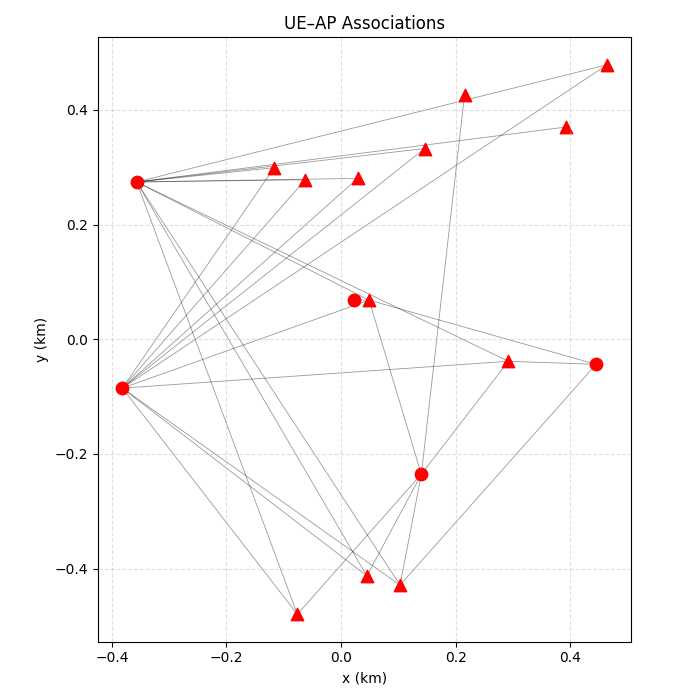

In [9]:
# Get x and y coordinates
x_ue = UE[:,0].real.flatten()
y_ue = UE[:,0].imag.flatten()
x_ap = AP[:,0].real.flatten()
y_ap = AP[:,0].imag.flatten()

fig, ax = plt.subplots(figsize=(7, 7))

# Draw association lines first (so they sit behind the markers)
for k in range(args.K):
    associated = np.where(ServingAPsBeta[:, k] == 1)[0]
    for m in associated:
        ax.plot([x_ue[k], x_ap[m]],
                [y_ue[k], y_ap[m]],
                'k-', linewidth=0.6, alpha=0.4, zorder=1)

# Plot APs and UEs on top
ax.scatter(x_ap, y_ap, c='red', marker='^', s=80)
ax.scatter(x_ue, y_ue, c='red', marker='o', s=80)

ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_xlabel('x (km)')
ax.set_ylabel('y (km)')
ax.set_title('UE–AP Associations')

plt.tight_layout()
plt.show()


In [10]:
#seeds=[0]
# We set the seed for the random number generator to ensure everyone gets the same realizations and to make your work reproducible when I need to verify
#your results 
Number_of_runs=100
seeds=np.arange(Number_of_runs).tolist() ## we want to run 100 different AP and UE locations and save the results to plot our CDF curves
#(See theory on monte carlo simulation)
SE_per_user=np.zeros((args.K,Number_of_runs),dtype=np.float32) # save SEs for each UE for all runs
Sum_SE=np.zeros(Number_of_runs,dtype=np.float32)
for trial in range(len(seeds)):
    
    args = Arguments()
   
    args.seed=seeds[trial]
    
    np.random.seed(args.seed)
    random.seed(args.seed)
    # place APs and UES
    UE,AP,R,distance,gainovernoisedB,gainovernoise,pilotIndex=setup(args.M,args.K,args.dcorr,args.delta,args.sigma,
                                                                    args.antennas,args.PNlog,args.tau_p,args.hap,args.hue)
    #Estimate channel between all APs and UEs
    H,Hhat,B,C=ChannelEstimates(args.M,args.antennas,args.channels,args.K,args.p,args.tau_p,pilotIndex,R)
    ### Compute Serving APs - M by K binary allocation matrix 
    ServingAPsBeta=BetaAPs(args.M,args.K,gainovernoise)
    #ServingAPsKmeans=yourfunction 
    SE,SINR,Power=compute_rates1(args.M,args.K,ServingAPsBeta,gainovernoise,args.Pd,args.tau_p,args.tau_c,B,R,pilotIndex)
    SE_per_user[:,trial]=SE
    Sum_SE[trial]=np.sum(SE)
    ### compute the SE for your algorithm and save it and the sum SE similar to above

Text(0, 0.5, 'CDF')

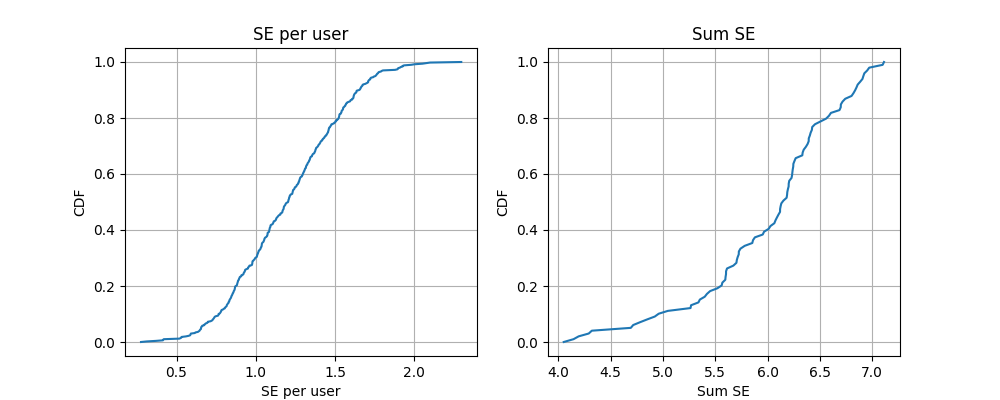

In [11]:
sort_per_ue=np.sort(SE_per_user.flatten())
sort_sum_SE=np.sort(Sum_SE)
y1=np.linspace(0,1,(Number_of_runs*args.K))
y2=np.linspace(0,1,Number_of_runs)
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(10,4))
ax1.plot(sort_per_ue,y1)
ax1.set_title('SE per user')
ax1.grid(True)
ax1.set_xlabel('SE per user')
ax1.set_ylabel('CDF')
ax2.plot(sort_sum_SE,y2)
ax2.set_title('Sum SE')
ax2.grid(True)
ax2.set_xlabel('Sum SE')
ax2.set_ylabel('CDF')
# write code to plot your results in the same plots as the above for comparison


Your task is to design an AP-UE allocation scheme using K-means. Save your allocation as an M*K matrix. Once you have successfully done this, you should be able to use the pre-defined functions to compute SE and thereafter write code to plot your results